In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df=pd.read_csv(r"C:\Users\user'\Desktop\Edure\dataset\Machine Learning\Mini Project\Customer Segmentation\Mall_Customers.csv")
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


# Data Type

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


# Data Details

In [49]:
print("===============Data Details====================\n")
print(f"Data Shape : {df.shape[0]} Rows X {df.shape[1]} Coloumns")
print(f"Data Size : {df.size}")
print(f"Dimension : {df.ndim}D")
print(f"Missing Values : {df.isna().sum().sum()}")
print(f"Missing Values : {df.isna().sum().sum()}")
print (f"Duplicates : {df.duplicated().sum()}\n")
print("=================================================")

===============Data Details====================

Data Shape : 200 Rows X 5 Coloumns
Data Size : 1000
Dimension : 2D
Missing Values : 0
Missing Values : 0
Duplicates : 0



# Statistical Summary

In [50]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Data Cleaning 

In [51]:
df.rename(columns={"Genre": "Gender"}, inplace=True)        # Rename Feature title to "Gender"
df=df.drop(columns=["CustomerID"])                          # Remove unwanted features ("Customer ID")
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [52]:
gender=df["Gender"]
gender.unique()

array(['Male', 'Female'], dtype=object)

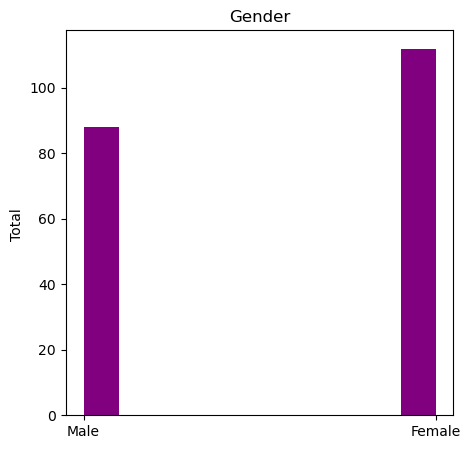

In [53]:
plt.figure(figsize=(5,5))
plt.hist(gender,color="purple")
plt.title("Gender")
plt.ylabel('Total ')
plt.show()

# Handle categorical data 

In [54]:
def gender(x):
    if x == "Male":
        return 0
    else:
        return 1

df["Gender"]=df["Gender"].apply(gender)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


# Exploratory Data Analysis (EDA)

### Distribution

In [ ]:
plt.figure(figsize=(20,10))
sns.pairplot(df,plot_kws={'color': 'purple'}, diag_kws={'color': 'purple'})
plt.show()

# Relationship

#### Annual Income Vs Spending Score

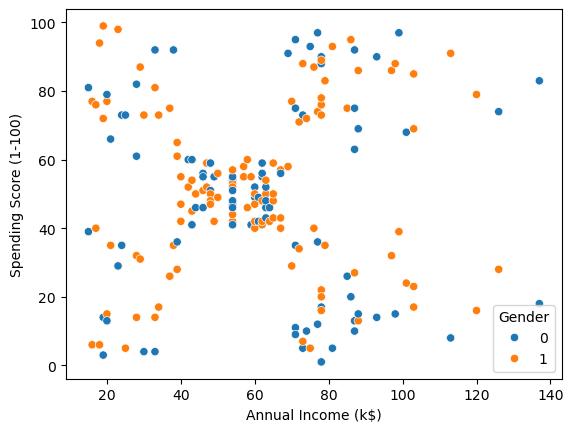

In [62]:
sns.scatterplot(data=df,x="Annual Income (k$)",y="Spending Score (1-100)",color="red", hue="Gender")
plt.legend()
plt.show()

#### Age Vs Spending Score

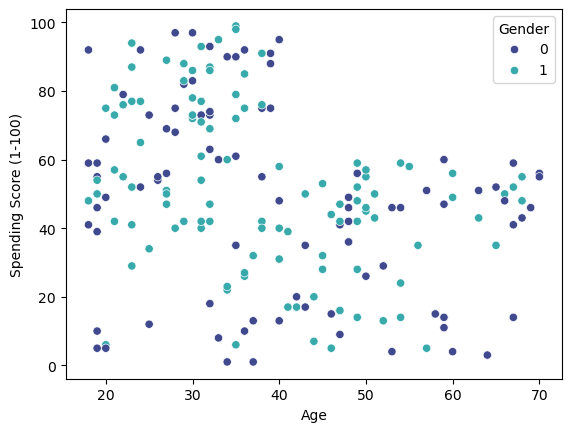

In [71]:
sns.scatterplot(data=df, x="Age", y="Spending Score (1-100)",hue="Gender",palette="mako")
plt.show()

## Correlation

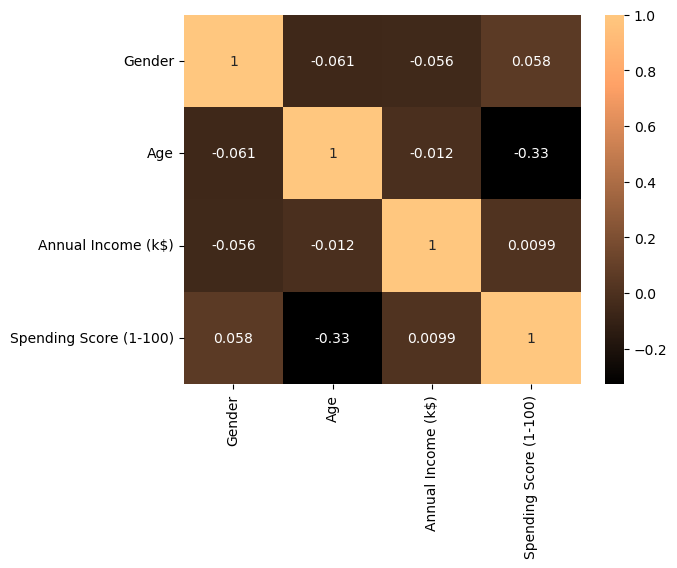

In [57]:
sns.heatmap(df.corr(),cmap="copper",annot=True)
plt.show()

# Clustering using KMean Clustering

In [77]:
from sklearn.cluster import KMeans
model=KMeans(n_clusters=3)

clusters=model.fit_predict(df)
clusters

D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2], dtype=int32)

In [81]:
df["clusters"]=clusters
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),clusters
0,0,19,15,39,0
1,0,21,15,81,0
2,1,20,16,6,1
3,1,23,16,77,0
4,1,31,17,40,0


In [82]:
df["clusters"].unique()

array([0, 1, 2], dtype=int32)

# Visualization of Cluster

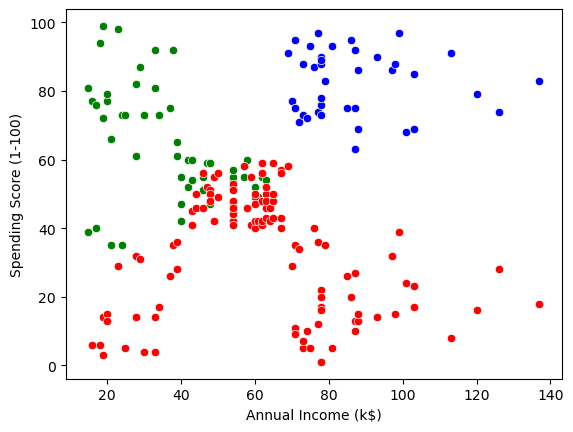

In [85]:
df0 = df[df['clusters'] == 0]
df1 = df[df['clusters'] == 1]
df2 = df[df['clusters'] == 2]
sns.scatterplot(data = df0, x = 'Annual Income (k$)', y = 'Spending Score (1-100)', color = 'green')
sns.scatterplot(data = df1, x = 'Annual Income (k$)', y = 'Spending Score (1-100)', color = 'red')
sns.scatterplot(data = df2, x = 'Annual Income (k$)', y = 'Spending Score (1-100)', color = 'blue')
plt.show()

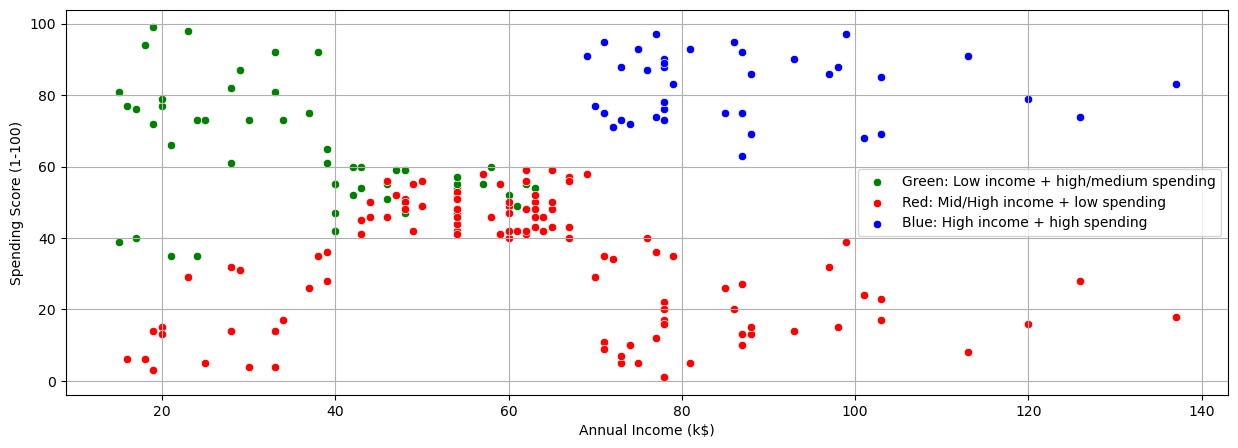

In [99]:
df0 = df[df['clusters'] == 0]
df1 = df[df['clusters'] == 1]
df2 = df[df['clusters'] == 2]

plt.figure(figsize=(15,5))
sns.scatterplot(data=df0,
                x='Annual Income (k$)', y='Spending Score (1-100)',
                color='green',
                label='Green: Low income + high/medium spending')

sns.scatterplot(data=df1,
                x='Annual Income (k$)', y='Spending Score (1-100)',
                color='red',
                label='Red: Mid/High income + low spending')

sns.scatterplot(data=df2,
                x='Annual Income (k$)', y='Spending Score (1-100)',
                color='blue',
                label='Blue: High income + high spending')
plt.grid()
plt.legend()
plt.show()

# Principal Component Analysis

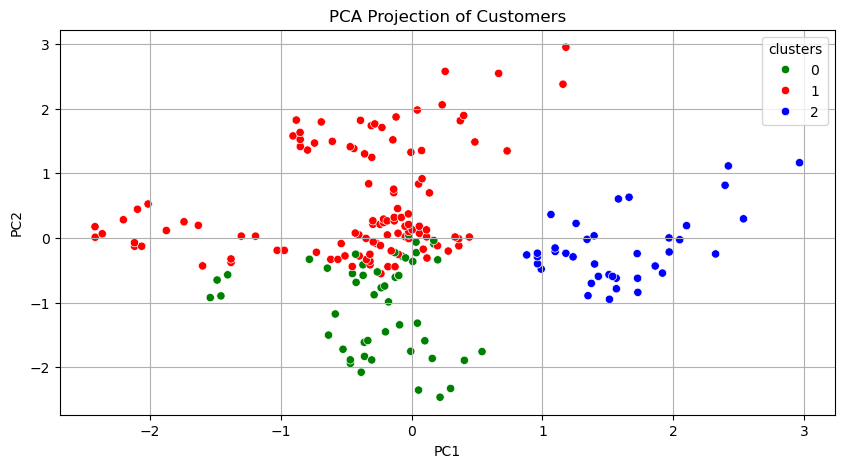

In [97]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = df.copy()
df_pca['PC1'] = X_pca[:, 0]
df_pca['PC2'] = X_pca[:, 1]


plt.figure(figsize=(10,5))

sns.scatterplot(data=df_pca,
                x='PC1', y='PC2',
                hue='clusters',
                palette=['green', 'red', 'blue'])
plt.grid()
plt.title('PCA Projection of Customers')
plt.show()